In [1]:
!pip install -q "tensorflow-datasets==4.9.9" "tensorflow-metadata==1.17.2" "protobuf==5.29.5" "importlib-resources"

In [2]:
import tensorflow as tf
print("TensorFlow:",tf.__version__)
print("GPUs:",tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers,models,regularizers,initializers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2,preprocess_input
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix,classification_report

In [4]:
from google.protobuf import __version__ as protobuf_version
print("TensorFlow:",tf.__version__)
print("Protobuf:",protobuf_version)
print("TFDS location:",tfds.__file__)
print("Has tfds.load:",hasattr(tfds,"load"))

TensorFlow: 2.20.0
Protobuf: 5.29.5
TFDS location: /usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py
Has tfds.load: True


In [5]:
IMG_SIZE=224
NUM_CLASSES=37
BATCH_SIZE=32
EPOCHS=3
SEED=42
AUTOTUNE=tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [6]:
builder=tfds.builder("oxford_iiit_pet")
print("Dataset:",builder.name)
print("Version:",builder.version)
print("Classes:",builder.info.features["label"].num_classes)

Dataset: oxford_iiit_pet
Version: 4.0.0
Classes: 37


In [7]:
builder.download_and_prepare()
print("Dataset prepared successfully")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ZOHVDR_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ZOHVDR_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Dataset prepared successfully


In [8]:
train_raw=tfds.load("oxford_iiit_pet",split="train[:80%]",as_supervised=True)
valid_raw=tfds.load("oxford_iiit_pet",split="train[80%:]",as_supervised=True)
test_raw=tfds.load("oxford_iiit_pet",split="test",as_supervised=True)

print("Training samples:",tf.data.experimental.cardinality(train_raw).numpy())
print("Validation samples:",tf.data.experimental.cardinality(valid_raw).numpy())
print("Test samples:",tf.data.experimental.cardinality(test_raw).numpy())

Training samples: 2944
Validation samples: 736
Test samples: 3669


In [9]:
class_names=builder.info.features["label"].names
print("Number of classes:",len(class_names))
print("Classes:",class_names)

Number of classes: 37
Classes: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


In [10]:
def preprocess_data(image,label):
    image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
    image=tf.cast(image,tf.float32)
    image=preprocess_input(image)
    return image,label

In [11]:
train_ds=train_raw.map(preprocess_data,num_parallel_calls=AUTOTUNE).shuffle(1000,seed=SEED).batch(BATCH_SIZE).prefetch(1)
valid_ds=valid_raw.map(preprocess_data,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(1)
test_ds=test_raw.map(preprocess_data,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(1)

print("Datasets created successfully")

Datasets created successfully


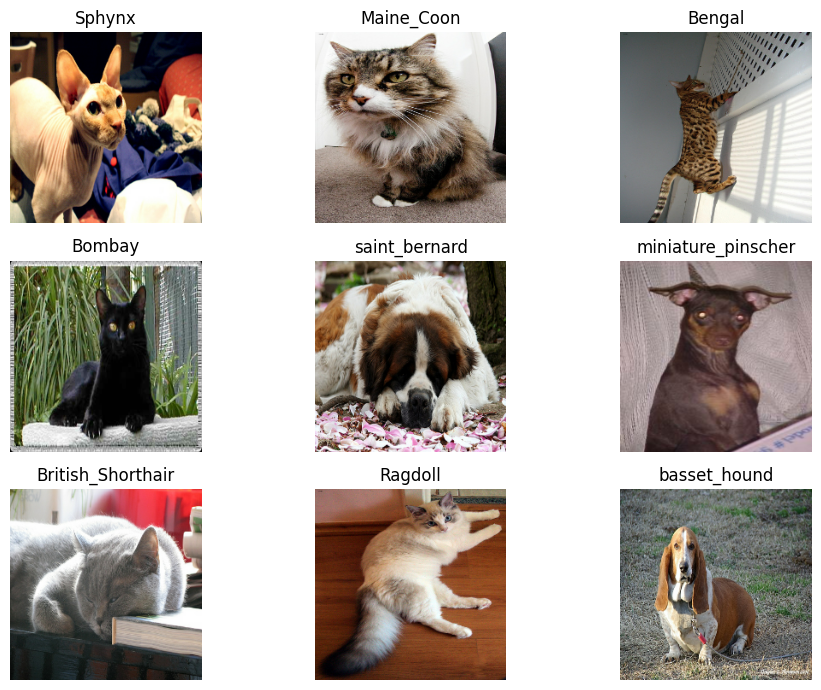

In [12]:
images,labels=next(iter(train_ds))

plt.figure(figsize=(10,7))

for i in range(9):
    plt.subplot(3,3,i+1)
    image=(images[i].numpy()+1)/2
    plt.imshow(np.clip(image,0,1))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
def create_model(init="he",dropout=0,l2_value=0,bn=False,optimizer="adam",lr=0.001,train_base=False):
    if init=="zero":
        kernel_init=initializers.Zeros()
    elif init=="random":
        kernel_init=initializers.RandomNormal(mean=0.0,stddev=0.05)
    elif init=="xavier":
        kernel_init=initializers.GlorotUniform()
    else:
        kernel_init=initializers.HeNormal()

    base=MobileNetV2(weights="imagenet",include_top=False,input_shape=(224,224,3))
    base.trainable=train_base

    inputs=layers.Input(shape=(224,224,3))
    x=base(inputs,training=False)
    x=layers.GlobalAveragePooling2D()(x)

    if bn:
        x=layers.BatchNormalization()(x)

    if dropout>0:
        x=layers.Dropout(dropout)(x)

    if l2_value>0:
        outputs=layers.Dense(NUM_CLASSES,kernel_initializer=kernel_init,kernel_regularizer=regularizers.l2(l2_value))(x)
    else:
        outputs=layers.Dense(NUM_CLASSES,kernel_initializer=kernel_init)(x)

    model=models.Model(inputs,outputs)

    if optimizer=="sgd":
        opt=tf.keras.optimizers.SGD(learning_rate=lr)
    elif optimizer=="momentum":
        opt=tf.keras.optimizers.SGD(learning_rate=lr,momentum=0.9)
    elif optimizer=="rmsprop":
        opt=tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt=tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt,loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=["accuracy"])

    return model

In [14]:
test_model=create_model()

print("Model created successfully")
print("Parameters:",test_model.count_params())

del test_model
tf.keras.backend.clear_session()
gc.collect()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model created successfully
Parameters: 2305381


0

In [15]:
initialization_methods=["zero","random","xavier","he"]
init_histories={}
init_results={}

In [16]:
for method in initialization_methods:
    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init=method,dropout=0,l2_value=0,bn=False,optimizer="adam",lr=0.001,train_base=False)

    start=time.time()

    history=model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    init_histories[method]=history.history
    init_results[method]=[history.history["loss"][-1],max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - accuracy: 0.7792 - loss: 1.1553 - val_accuracy: 0.9008 - val_loss: 0.4436
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.9443 - loss: 0.2838 - val_accuracy: 0.9062 - val_loss: 0.3383
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9701 - loss: 0.1806 - val_accuracy: 0.8995 - val_loss: 0.3111
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step - accuracy: 0.6607 - loss: 1.3486 - val_accuracy: 0.8478 - val_loss: 0.5359
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.9229 - loss: 0.3286 - val_accuracy: 0.8818 - val_loss: 0.4070
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.9531 - loss: 0.2004 - val_accuracy: 0.8899 - val_loss: 0.3442
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step - accuracy: 0.6923 - loss: 1.3070 - val_accuracy: 0.8709 - val_loss: 0.5197
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9283 - loss: 0.3187 - val_accuracy: 0.9022

In [17]:
init_table=pd.DataFrame(init_results,index=["Final Training Loss","Best Validation Accuracy","Training Time"]).T
print(init_table)

        Final Training Loss  Best Validation Accuracy  Training Time
zero               0.180596                 90.625000      65.001467
random             0.200449                 88.994563      50.663953
xavier             0.198997                 90.217394      48.982579
he                 0.196394                 90.217394      56.301017


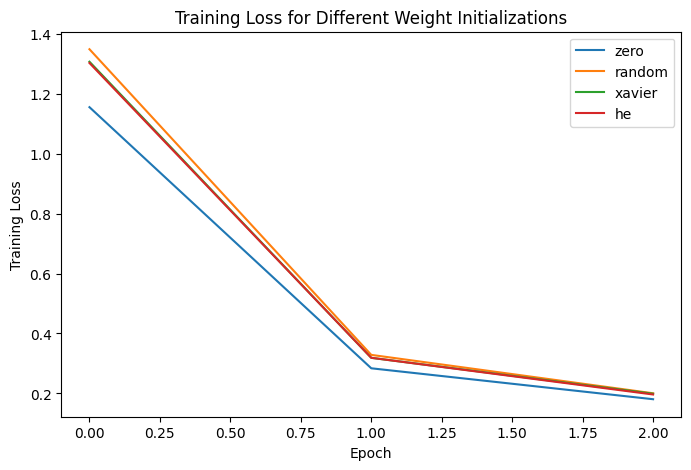

In [18]:
plt.figure(figsize=(8,5))

for method in initialization_methods:
    plt.plot(init_histories[method]["loss"],label=method)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Weight Initializations")
plt.legend()
plt.show()

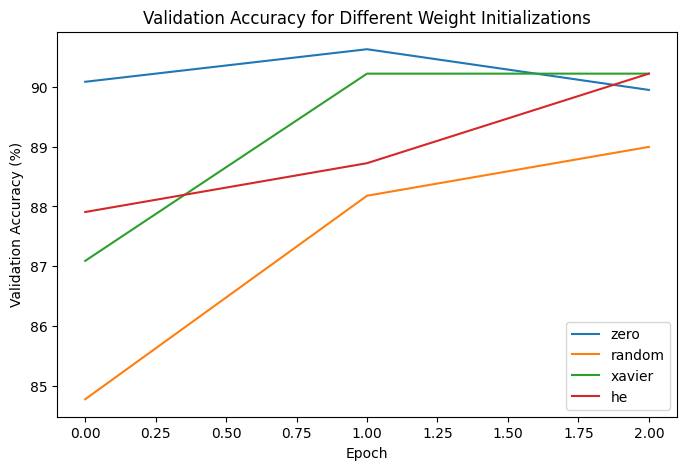

In [19]:
plt.figure(figsize=(8,5))

for method in initialization_methods:
    plt.plot(np.array(init_histories[method]["val_accuracy"])*100,label=method)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Different Weight Initializations")
plt.legend()
plt.show()

In [20]:
best_init=max(init_results,key=lambda x:init_results[x][1])
print("Best Initialization:",best_init)
print("Best Validation Accuracy:",init_results[best_init][1])

Best Initialization: zero
Best Validation Accuracy: 90.625


In [21]:
regularization_configs={
    "No Regularization":{"dropout":0,"l2":0,"bn":False},
    "L2":{"dropout":0,"l2":0.0001,"bn":False},
    "Dropout":{"dropout":0.5,"l2":0,"bn":False},
    "Batch Normalization":{"dropout":0,"l2":0,"bn":True}
}

reg_histories={}
reg_results={}

In [22]:
for name,config in regularization_configs.items():
    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init=best_init,dropout=config["dropout"],l2_value=config["l2"],bn=config["bn"],optimizer="adam",lr=0.001,train_base=False)

    start=time.time()

    history=model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    reg_histories[name]=history.history
    reg_results[name]=[history.history["loss"][-1],max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - accuracy: 0.7680 - loss: 1.1600 - val_accuracy: 0.8967 - val_loss: 0.4588
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9463 - loss: 0.2838 - val_accuracy: 0.9062 - val_loss: 0.3451
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.9667 - loss: 0.1796 - val_accuracy: 0.9103 - val_loss: 0.3080
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.7779 - loss: 1.1657 - val_accuracy: 0.8913 - val_loss: 0.4466
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.9416 - loss: 0.2892 - val_accuracy: 0.9198 - val_loss: 0.3446
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9657 - loss: 0.1846 - val_accuracy: 0.9158 - val_loss: 0.3020
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 198ms/step - accuracy: 0.7422 - loss: 1.3593 - val_accuracy: 0.9090 - val_loss: 0.5181
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9209 - loss: 0.3777 - val_accuracy: 0.9130

In [23]:
reg_table=pd.DataFrame(reg_results,index=["Final Training Loss","Best Validation Accuracy","Training Time"]).T
print(reg_table)

                     Final Training Loss  Best Validation Accuracy  \
No Regularization               0.179600                 91.032606   
L2                              0.184624                 91.983694   
Dropout                         0.258233                 91.304350   
Batch Normalization             0.085766                 91.440219   

                     Training Time  
No Regularization        56.525977  
L2                       67.256145  
Dropout                  60.320081  
Batch Normalization      47.338211  


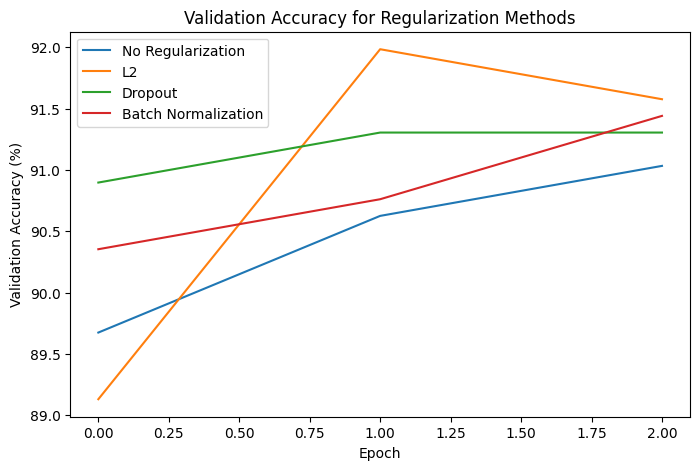

In [24]:
plt.figure(figsize=(8,5))

for name in regularization_configs:
    plt.plot(np.array(reg_histories[name]["val_accuracy"])*100,label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Regularization Methods")
plt.legend()
plt.show()

In [25]:
best_reg=max(reg_results,key=lambda x:reg_results[x][1])
print("Best Regularization:",best_reg)
print("Best Validation Accuracy:",reg_results[best_reg][1])

Best Regularization: L2
Best Validation Accuracy: 91.9836938381195


In [26]:
bn_histories={}
bn_results={}

In [27]:
for name,use_bn in [("Without BN",False),("With BN",True)]:
    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init=best_init,dropout=0,l2_value=0,bn=use_bn,optimizer="adam",lr=0.001,train_base=False)

    start=time.time()

    history=model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    bn_histories[name]=history.history
    bn_results[name]=[max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step - accuracy: 0.7711 - loss: 1.1597 - val_accuracy: 0.8859 - val_loss: 0.4624
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9467 - loss: 0.2854 - val_accuracy: 0.9158 - val_loss: 0.3397
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - accuracy: 0.9620 - loss: 0.1824 - val_accuracy: 0.9117 - val_loss: 0.3086
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - accuracy: 0.8441 - loss: 0.7459 - val_accuracy: 0.9035 - val_loss: 0.4722
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9592 - loss: 0.1628 - val_accuracy: 0.9076 - val_loss: 0.3188
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9864 - loss: 0.0816 - val_accuracy: 0.9076 - val_loss: 0.2916


In [28]:
bn_table=pd.DataFrame(bn_results,index=["Best Validation Accuracy","Training Time"]).T
print(bn_table)

            Best Validation Accuracy  Training Time
Without BN                 91.576087      56.829587
With BN                    90.760869      48.708577


In [29]:
optimizers=["sgd","momentum","rmsprop","adam"]
optimizer_histories={}
optimizer_results={}

In [30]:
for opt_name in optimizers:
    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init=best_init,dropout=0,l2_value=0,bn=False,optimizer=opt_name,lr=0.001,train_base=False)

    start=time.time()

    history=model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    optimizer_histories[opt_name]=history.history
    optimizer_results[opt_name]=[history.history["loss"][-1],max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.5842 - loss: 3.4776 - val_accuracy: 0.7921 - val_loss: 3.3423
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.8251 - loss: 3.2069 - val_accuracy: 0.8166 - val_loss: 3.0910
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.8614 - loss: 2.9545 - val_accuracy: 0.8383 - val_loss: 2.8565
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.6304 - loss: 2.6752 - val_accuracy: 0.8723 - val_loss: 1.7461
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.9008 - loss: 1.2473 - val_accuracy: 0.8927 - val_loss: 0.9692
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.9168 - loss: 0.7656 - val_accuracy: 0.9062 - val_loss: 0.7014
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 140ms/step - accuracy: 0.7955 - loss: 1.0287 - val_accuracy: 0.9008 - val_loss: 0.4198
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9368 - loss: 0.2603 - val_accuracy: 0.904

In [31]:
optimizer_table=pd.DataFrame(optimizer_results,index=["Final Training Loss","Best Validation Accuracy","Training Time"]).T
print(optimizer_table)

          Final Training Loss  Best Validation Accuracy  Training Time
sgd                  2.954533                 83.831519      46.914393
momentum             0.765566                 90.625000      47.642247
rmsprop              0.159553                 90.489131      46.566779
adam                 0.177568                 91.440219      47.388297


In [32]:
best_optimizer=max(optimizer_results,key=lambda x:optimizer_results[x][1])
print("Best Optimizer:",best_optimizer)
print("Best Validation Accuracy:",optimizer_results[best_optimizer][1])

Best Optimizer: adam
Best Validation Accuracy: 91.4402186870575


In [33]:
learning_rates=[0.001,0.0001]
lr_histories={}
lr_results={}

In [34]:
for lr in learning_rates:
    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init="he",dropout=0,l2_value=0,bn=False,optimizer="adam",lr=lr,train_base=False)

    start=time.time()

    history=model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    lr_histories[lr]=history.history
    lr_results[lr]=[max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - accuracy: 0.6885 - loss: 1.2868 - val_accuracy: 0.8655 - val_loss: 0.5196
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9300 - loss: 0.3085 - val_accuracy: 0.8899 - val_loss: 0.3893
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - accuracy: 0.9582 - loss: 0.1931 - val_accuracy: 0.8940 - val_loss: 0.3506
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.1393 - loss: 3.2614 - val_accuracy: 0.3288 - val_loss: 2.6575
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.5017 - loss: 2.2577 - val_accuracy: 0.6495 - val_loss: 1.8895
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.7262 - loss: 1.5956 - val_accuracy: 0.7609 - val_loss: 1.3882


In [35]:
lr_table=pd.DataFrame(lr_results,index=["Best Validation Accuracy","Training Time"]).T
print(lr_table)

        Best Validation Accuracy  Training Time
0.0010                 89.402175      57.969666
0.0001                 76.086956      48.280857


In [36]:
batch_sizes=[16,32,64]
batch_histories={}
batch_results={}

In [37]:
for batch_size in batch_sizes:
    temp_train=train_raw.map(preprocess_data,num_parallel_calls=1).shuffle(1000,seed=SEED).batch(batch_size).prefetch(1)
    temp_valid=valid_raw.map(preprocess_data,num_parallel_calls=1).batch(batch_size).prefetch(1)

    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init="he",dropout=0,l2_value=0,bn=False,optimizer="adam",lr=0.001,train_base=False)

    start=time.time()

    history=model.fit(temp_train,validation_data=temp_valid,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    batch_histories[batch_size]=history.history
    batch_results[batch_size]=[max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    del temp_train
    del temp_valid
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.7388 - loss: 1.0423 - val_accuracy: 0.8899 - val_loss: 0.4304
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9409 - loss: 0.2417 - val_accuracy: 0.8913 - val_loss: 0.3521
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9728 - loss: 0.1394 - val_accuracy: 0.9062 - val_loss: 0.3101
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.6783 - loss: 1.3428 - val_accuracy: 0.8628 - val_loss: 0.5290
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9178 - loss: 0.3273 - val_accuracy: 0.8750 - val_loss: 0.4123
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.9616 - loss: 0.2018 - val_accuracy: 0.8940 - val_loss: 0.3520
Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 393ms/step - accuracy: 0.5819 - loss: 1.7766 - val_accuracy: 0.8410 - val_loss: 0.6899
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.9134 - loss: 0.4360 - val_accuracy:

In [38]:
batch_table=pd.DataFrame(batch_results,index=["Best Validation Accuracy","Training Time"]).T
print(batch_table)

    Best Validation Accuracy  Training Time
16                 90.625000      58.341779
32                 89.402175      48.601597
64                 87.907606      70.238972


In [39]:
dropout_rates=[0,0.25,0.5]
dropout_histories={}
dropout_results={}

In [40]:
for rate in dropout_rates:
    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init="he",dropout=rate,l2_value=0,bn=False,optimizer="adam",lr=0.001,train_base=False)

    start=time.time()

    history=model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

    elapsed=time.time()-start

    dropout_histories[rate]=history.history
    dropout_results[rate]=[max(history.history["val_accuracy"])*100,elapsed]

    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.6933 - loss: 1.2827 - val_accuracy: 0.8791 - val_loss: 0.5071
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9239 - loss: 0.3162 - val_accuracy: 0.9008 - val_loss: 0.3591
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9555 - loss: 0.1951 - val_accuracy: 0.8899 - val_loss: 0.3432
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - accuracy: 0.6230 - loss: 1.4701 - val_accuracy: 0.8614 - val_loss: 0.5465
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.9039 - loss: 0.3796 - val_accuracy: 0.8791 - val_loss: 0.4001
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.9372 - loss: 0.2568 - val_accuracy: 0.8913 - val_loss: 0.3467
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.5231 - loss: 1.7858 - val_accuracy: 0.8723 - val_loss: 0.5784
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8536 - loss: 0.5282 - val_accuracy: 0.888

In [41]:
dropout_table=pd.DataFrame(dropout_results,index=["Best Validation Accuracy","Training Time"]).T
print(dropout_table)

      Best Validation Accuracy  Training Time
0.00                 90.081519      56.073675
0.25                 89.130437      57.805985
0.50                 91.304350      61.916099


In [42]:
best_lr=max(lr_results,key=lambda x:lr_results[x][0])
best_batch=max(batch_results,key=lambda x:batch_results[x][0])
best_dropout=max(dropout_results,key=lambda x:dropout_results[x][0])

print("Best Initialization:",best_init)
print("Best Optimizer:",best_optimizer)
print("Best Learning Rate:",best_lr)
print("Best Batch Size:",best_batch)
print("Best Dropout:",best_dropout)

Best Initialization: zero
Best Optimizer: adam
Best Learning Rate: 0.001
Best Batch Size: 16
Best Dropout: 0.5


In [43]:
tf.keras.backend.clear_session()
gc.collect()

feature_model=create_model(init="he",dropout=best_dropout,l2_value=0,bn=False,optimizer="adam",lr=best_lr,train_base=False)

feature_start=time.time()

feature_history=feature_model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

feature_time=time.time()-feature_start

feature_accuracy=max(feature_history.history["val_accuracy"])*100

print("Feature Extraction Accuracy:",feature_accuracy)
print("Feature Extraction Training Time:",feature_time)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.5109 - loss: 1.8204 - val_accuracy: 0.8560 - val_loss: 0.6121
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.8410 - loss: 0.5409 - val_accuracy: 0.8995 - val_loss: 0.3928
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.8981 - loss: 0.3536 - val_accuracy: 0.8981 - val_loss: 0.3454
Feature Extraction Accuracy: 89.94565010070801
Feature Extraction Training Time: 77.893310546875


In [44]:
fine_model=feature_model
fine_base=fine_model.layers[1]
fine_base.trainable=True

for layer in fine_base.layers[:-20]:
    layer.trainable=False

for layer in fine_base.layers[-20:]:
    layer.trainable=True

fine_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=["accuracy"])

fine_start=time.time()

fine_history=fine_model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

fine_time=time.time()-fine_start

fine_accuracy=max(fine_history.history["val_accuracy"])*100

print("Fine-Tuning Accuracy:",fine_accuracy)
print("Fine-Tuning Training Time:",fine_time)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.8750 - loss: 0.3881 - val_accuracy: 0.9117 - val_loss: 0.2864
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9344 - loss: 0.2118 - val_accuracy: 0.9158 - val_loss: 0.2764
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9596 - loss: 0.1405 - val_accuracy: 0.9130 - val_loss: 0.2705
Fine-Tuning Accuracy: 91.576087474823
Fine-Tuning Training Time: 54.40501260757446


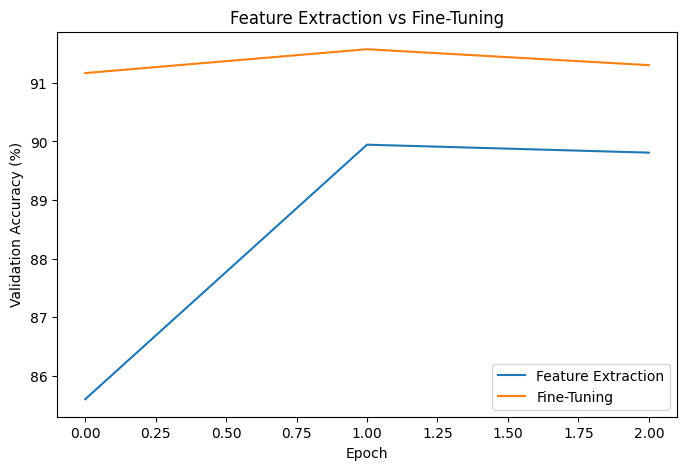

In [45]:
plt.figure(figsize=(8,5))
plt.plot(np.array(feature_history.history["val_accuracy"])*100,label="Feature Extraction")
plt.plot(np.array(fine_history.history["val_accuracy"])*100,label="Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.show()

In [46]:
cv_images=[]
cv_labels=[]

for image,label in train_raw:
    image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
    image=tf.cast(image,tf.uint8)
    cv_images.append(image.numpy())
    cv_labels.append(label.numpy())

cv_images=np.stack(cv_images)
cv_labels=np.array(cv_labels,dtype=np.int32)

print("CV Images:",cv_images.shape)
print("CV Labels:",cv_labels.shape)
print("CV Image Memory:",round(cv_images.nbytes/1024**3,2),"GB")

CV Images: (2944, 224, 224, 3)
CV Labels: (2944,)
CV Image Memory: 0.41 GB


In [47]:
kf=KFold(n_splits=5,shuffle=True,random_state=SEED)
folds=list(kf.split(cv_images))

print("Number of folds:",len(folds))

Number of folds: 5


In [48]:
cv_scores=[]

for fold,(train_index,val_index) in enumerate(folds):
    print("Starting Fold",fold+1)

    x_train=cv_images[train_index]
    y_train=cv_labels[train_index]
    x_val=cv_images[val_index]
    y_val=cv_labels[val_index]

    train_fold=tf.data.Dataset.from_tensor_slices((x_train,y_train))
    train_fold=train_fold.shuffle(1000,seed=SEED).map(preprocess_data,num_parallel_calls=1).batch(32).prefetch(1)

    val_fold=tf.data.Dataset.from_tensor_slices((x_val,y_val))
    val_fold=val_fold.map(preprocess_data,num_parallel_calls=1).batch(32).prefetch(1)

    tf.keras.backend.clear_session()
    gc.collect()

    model=create_model(init="he",dropout=best_dropout,l2_value=0,bn=False,optimizer="adam",lr=best_lr,train_base=False)

    history=model.fit(train_fold,validation_data=val_fold,epochs=2,verbose=1)

    score=max(history.history["val_accuracy"])*100
    cv_scores.append(score)

    print("Fold",fold+1,"Accuracy:",score)

    del model
    del history
    del train_fold
    del val_fold
    del x_train
    del y_train
    del x_val
    del y_val

    tf.keras.backend.clear_session()
    gc.collect()

Starting Fold 1
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - accuracy: 0.4713 - loss: 2.0231 - val_accuracy: 0.8506 - val_loss: 0.6585
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8251 - loss: 0.6204 - val_accuracy: 0.8659 - val_loss: 0.4228
Fold 1 Accuracy: 86.58743500709534
Starting Fold 2
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 220ms/step - accuracy: 0.4713 - loss: 1.9696 - val_accuracy: 0.8591 - val_loss: 0.6621
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8395 - loss: 0.6002 - val_accuracy: 0.8879 - val_loss: 0.4341
Fold 2 Accuracy: 88.79456520080566
Starting Fold 3
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 208ms/step - accuracy: 0.4544 - loss: 2.0765 - val_accuracy: 0.8438 - val_loss: 0.6713
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8242 - loss: 0.6275 - val_accuracy: 0.8913 - val_loss: 0.4209
Fold 3 Accuracy: 89.13412690162659
Starting Fold 4
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 25s 213ms/step - accuracy: 0.471

In [49]:
cv_scores=np.array(cv_scores)

print("Fold 1:",cv_scores[0])
print("Fold 2:",cv_scores[1])
print("Fold 3:",cv_scores[2])
print("Fold 4:",cv_scores[3])
print("Fold 5:",cv_scores[4])
print("Mean Accuracy:",np.mean(cv_scores))
print("Standard Deviation:",np.std(cv_scores))

Fold 1: 86.58743500709534
Fold 2: 88.79456520080566
Fold 3: 89.13412690162659
Fold 4: 86.58743500709534
Fold 5: 86.73469424247742
Mean Accuracy: 87.56765127182007
Standard Deviation: 1.1467021367303494


In [50]:
print("5-Fold Cross-Validation Accuracy:",round(np.mean(cv_scores),2),"±",round(np.std(cv_scores),2),"%")

5-Fold Cross-Validation Accuracy: 87.57 ± 1.15 %


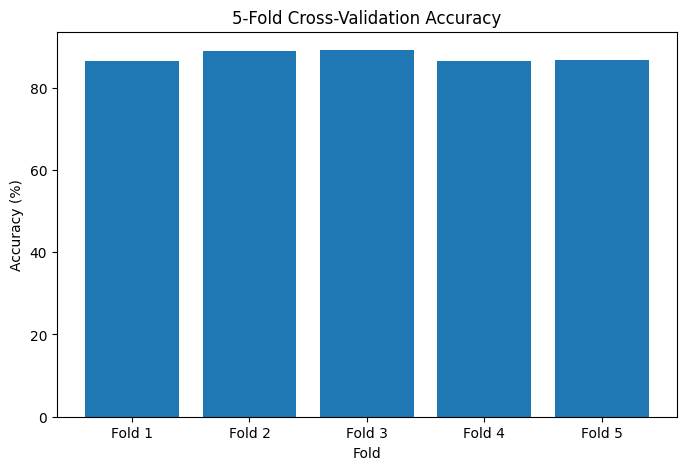

In [51]:
plt.figure(figsize=(8,5))
plt.bar(["Fold 1","Fold 2","Fold 3","Fold 4","Fold 5"],cv_scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.show()

In [52]:
del cv_images
del cv_labels
del folds
del kf
gc.collect()
tf.keras.backend.clear_session()

In [53]:
final_model=create_model(init="he",dropout=best_dropout,l2_value=0,bn=False,optimizer="adam",lr=best_lr,train_base=False)

print("Final model created successfully")
print("Parameters:",final_model.count_params())

Final model created successfully
Parameters: 2305381


In [54]:
final_start=time.time()

final_history=final_model.fit(train_ds,validation_data=valid_ds,epochs=EPOCHS,verbose=1)

final_training_time=time.time()-final_start

print("Final Training Time:",final_training_time)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - accuracy: 0.5309 - loss: 1.7741 - val_accuracy: 0.8641 - val_loss: 0.5634
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.8461 - loss: 0.5368 - val_accuracy: 0.8913 - val_loss: 0.3834
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.8923 - loss: 0.3598 - val_accuracy: 0.8927 - val_loss: 0.3507
Final Training Time: 46.650906801223755


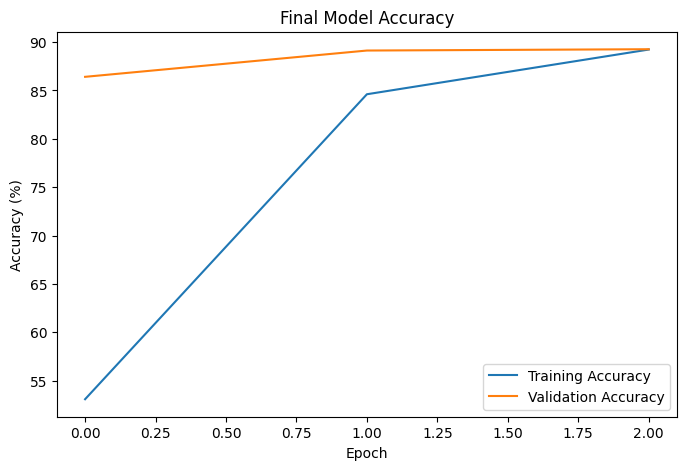

In [55]:
plt.figure(figsize=(8,5))
plt.plot(np.array(final_history.history["accuracy"])*100,label="Training Accuracy")
plt.plot(np.array(final_history.history["val_accuracy"])*100,label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Final Model Accuracy")
plt.legend()
plt.show()

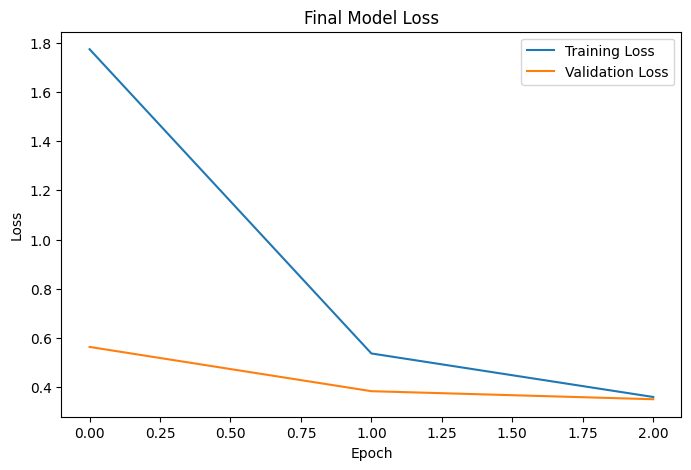

In [56]:
plt.figure(figsize=(8,5))
plt.plot(final_history.history["loss"],label="Training Loss")
plt.plot(final_history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Loss")
plt.legend()
plt.show()

In [57]:
test_loss,test_accuracy=final_model.evaluate(test_ds,verbose=1)

print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy*100)

115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 187ms/step - accuracy: 0.8787 - loss: 0.3906
Test Loss: 0.3905515968799591
Test Accuracy: 87.87135481834412


In [58]:
y_true=[]
y_pred=[]

for images,labels in test_ds:
    predictions=final_model.predict(images,verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions,axis=1))

y_true=np.array(y_true)
y_pred=np.array(y_pred)

print("Predictions generated successfully")
print("Number of predictions:",len(y_pred))

Predictions generated successfully
Number of predictions: 3669


In [59]:
report=classification_report(y_true,y_pred,target_names=class_names,output_dict=True,zero_division=0)

precision=report["weighted avg"]["precision"]
recall=report["weighted avg"]["recall"]
f1=report["weighted avg"]["f1-score"]

print("Precision:",precision*100)
print("Recall:",recall*100)
print("F1-score:",f1*100)

Precision: 88.90665137166162
Recall: 87.87135459253203
F1-score: 87.61351960522462


In [60]:
print(classification_report(y_true,y_pred,target_names=class_names,zero_division=0))

                            precision    recall  f1-score   support

                Abyssinian       0.92      0.80      0.85        98
          american_bulldog       0.72      0.87      0.79       100
 american_pit_bull_terrier       0.81      0.59      0.68       100
              basset_hound       0.86      0.92      0.89       100
                    beagle       0.93      0.81      0.87       100
                    Bengal       0.65      0.84      0.73       100
                    Birman       0.78      0.80      0.79       100
                    Bombay       0.86      0.89      0.87        88
                     boxer       0.86      0.94      0.90        99
         British_Shorthair       0.91      0.29      0.44       100
                 chihuahua       0.95      0.87      0.91       100
              Egyptian_Mau       0.90      0.72      0.80        97
    english_cocker_spaniel       0.95      0.96      0.96       100
            english_setter       0.96      0.93

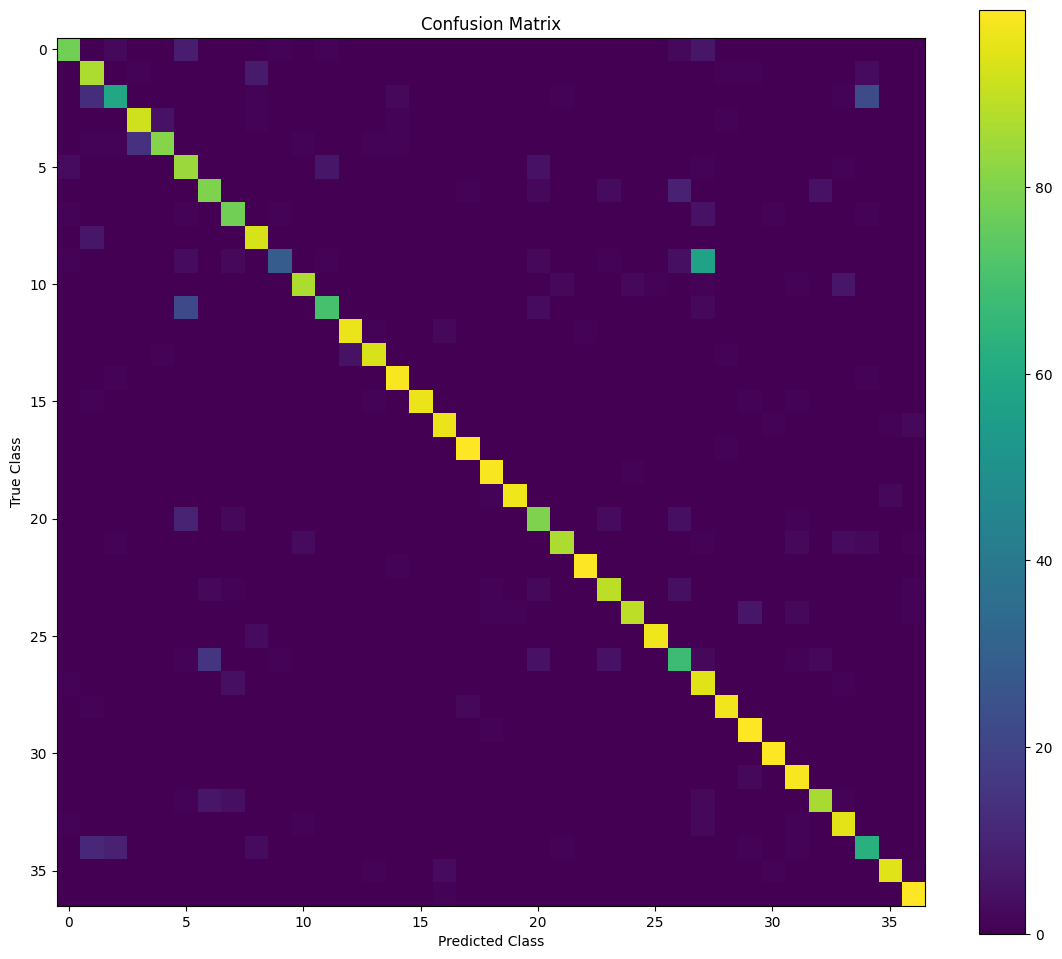

In [61]:
cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize=(14,12))
plt.imshow(cm)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [62]:
class_accuracy=cm.diagonal()/cm.sum(axis=1)

best_class_index=np.argmax(class_accuracy)
worst_class_index=np.argmin(class_accuracy)

print("Best Classified Class:",class_names[best_class_index])
print("Best Class Accuracy:",class_accuracy[best_class_index]*100)
print("Lowest Classified Class:",class_names[worst_class_index])
print("Lowest Class Accuracy:",class_accuracy[worst_class_index]*100)

Best Classified Class: scottish_terrier
Best Class Accuracy: 100.0
Lowest Classified Class: British_Shorthair
Lowest Class Accuracy: 28.999999999999996


In [63]:
final_results=pd.DataFrame({
    "Metric":[
        "5-Fold CV Mean Accuracy",
        "5-Fold CV Standard Deviation",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time",
        "Number of Parameters"
    ],
    "Value":[
        np.mean(cv_scores),
        np.std(cv_scores),
        test_accuracy*100,
        precision*100,
        recall*100,
        f1*100,
        final_training_time,
        final_model.count_params()
    ]
})

print(final_results)

                         Metric         Value
0       5-Fold CV Mean Accuracy  8.756765e+01
1  5-Fold CV Standard Deviation  1.146702e+00
2                 Test Accuracy  8.787135e+01
3                     Precision  8.890665e+01
4                        Recall  8.787135e+01
5                      F1-score  8.761352e+01
6                 Training Time  4.665091e+01
7          Number of Parameters  2.305381e+06


In [64]:
overall_results=pd.DataFrame({
    "Experiment":[
        "Weight Initialization",
        "Regularization",
        "Batch Normalization",
        "Optimizer",
        "Learning Rate",
        "Batch Size",
        "Dropout",
        "Feature Extraction",
        "Fine-Tuning"
    ],
    "Best Setting":[
        best_init,
        best_reg,
        "Without BN" if bn_results["Without BN"][0]>=bn_results["With BN"][0] else "With BN",
        best_optimizer,
        best_lr,
        best_batch,
        best_dropout,
        "Frozen MobileNetV2",
        "0.0001"
    ],
    "Validation Accuracy":[
        init_results[best_init][1],
        reg_results[best_reg][1],
        max(bn_results["Without BN"][0],bn_results["With BN"][0]),
        optimizer_results[best_optimizer][1],
        lr_results[best_lr][0],
        batch_results[best_batch][0],
        dropout_results[best_dropout][0],
        feature_accuracy,
        fine_accuracy
    ]
})

print(overall_results)

              Experiment        Best Setting  Validation Accuracy
0  Weight Initialization                zero            90.625000
1         Regularization                  L2            91.983694
2    Batch Normalization          Without BN            91.576087
3              Optimizer                adam            91.440219
4          Learning Rate               0.001            89.402175
5             Batch Size                  16            90.625000
6                Dropout                 0.5            91.304350
7     Feature Extraction  Frozen MobileNetV2            89.945650
8            Fine-Tuning              0.0001            91.576087


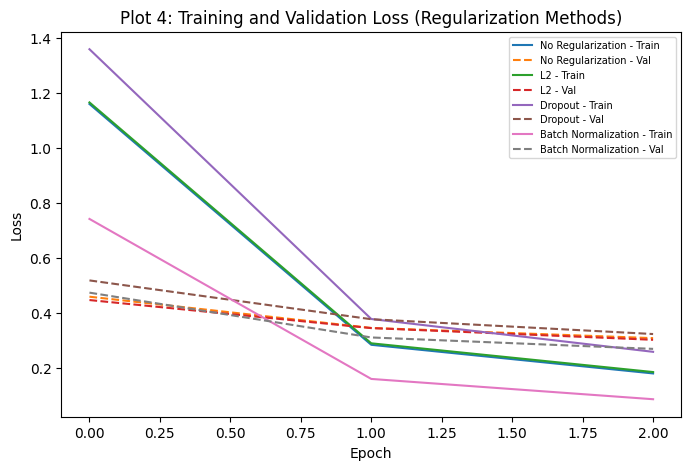

In [65]:
plt.figure(figsize=(8,5))
for name in regularization_configs:
    plt.plot(reg_histories[name]["loss"],linestyle="-",label=f"{name} - Train")
    plt.plot(reg_histories[name]["val_loss"],linestyle="--",label=f"{name} - Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 4: Training and Validation Loss (Regularization Methods)")
plt.legend(fontsize=7)
plt.savefig("plot4_reg_loss.png",dpi=150,bbox_inches="tight")
plt.show()

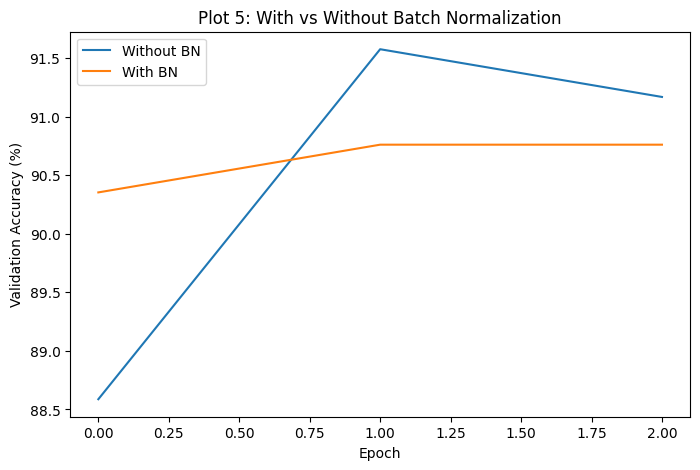

In [66]:
plt.figure(figsize=(8,5))
for name in bn_histories:
    plt.plot(np.array(bn_histories[name]["val_accuracy"])*100,label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs Without Batch Normalization")
plt.legend()
plt.savefig("plot5_bn_vs_nobn.png",dpi=150,bbox_inches="tight")
plt.show()

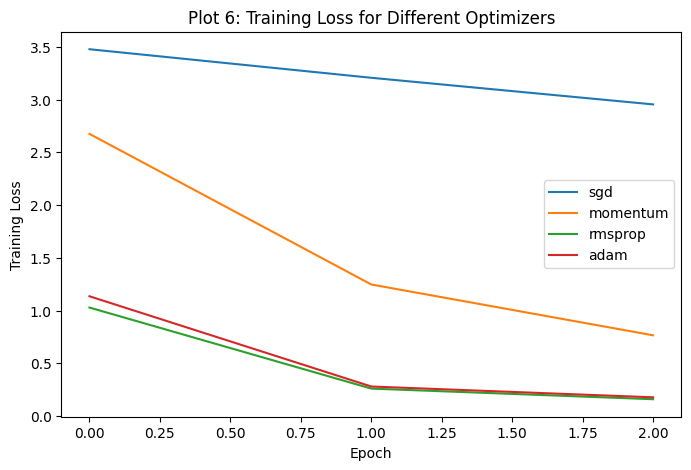

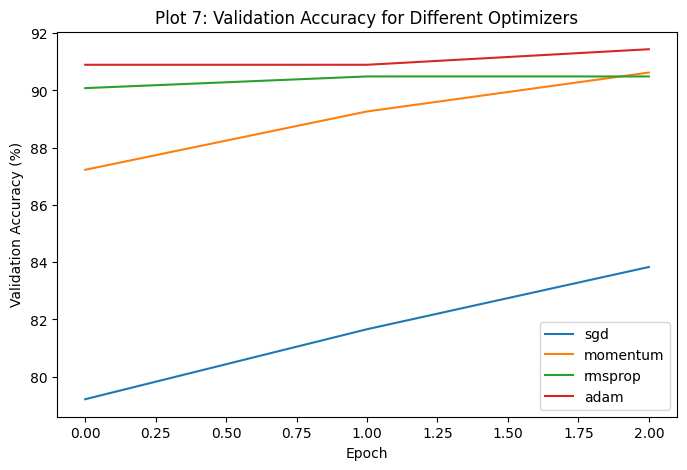

In [67]:
plt.figure(figsize=(8,5))
for opt_name in optimizers:
    plt.plot(optimizer_histories[opt_name]["loss"],label=opt_name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss for Different Optimizers")
plt.legend()
plt.savefig("plot6_optimizer_loss.png",dpi=150,bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
for opt_name in optimizers:
    plt.plot(np.array(optimizer_histories[opt_name]["val_accuracy"])*100,label=opt_name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy for Different Optimizers")
plt.legend()
plt.savefig("plot7_optimizer_valacc.png",dpi=150,bbox_inches="tight")
plt.show()

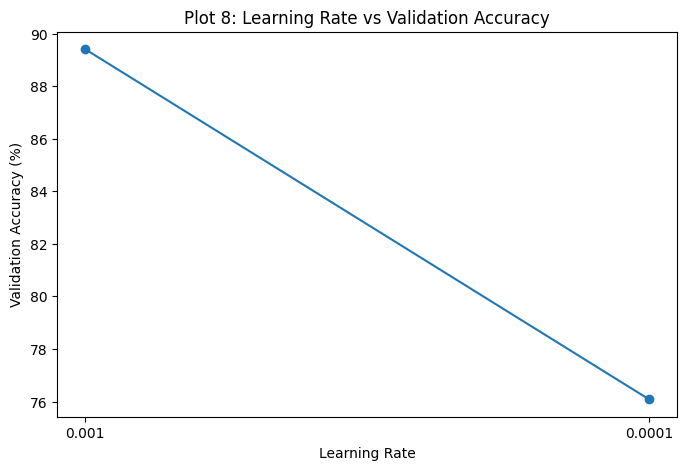

In [68]:
plt.figure(figsize=(8,5))
lrs=list(lr_results.keys())
accs=[lr_results[lr][0] for lr in lrs]
plt.plot([str(lr) for lr in lrs],accs,marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.savefig("plot8_lr_vs_acc.png",dpi=150,bbox_inches="tight")
plt.show()

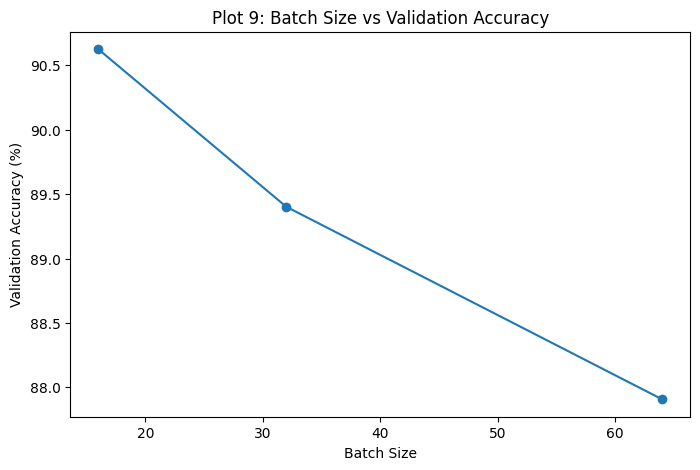

In [69]:
plt.figure(figsize=(8,5))
sizes=list(batch_results.keys())
accs=[batch_results[b][0] for b in sizes]
plt.plot(sizes,accs,marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.savefig("plot9_batchsize_vs_acc.png",dpi=150,bbox_inches="tight")
plt.show()

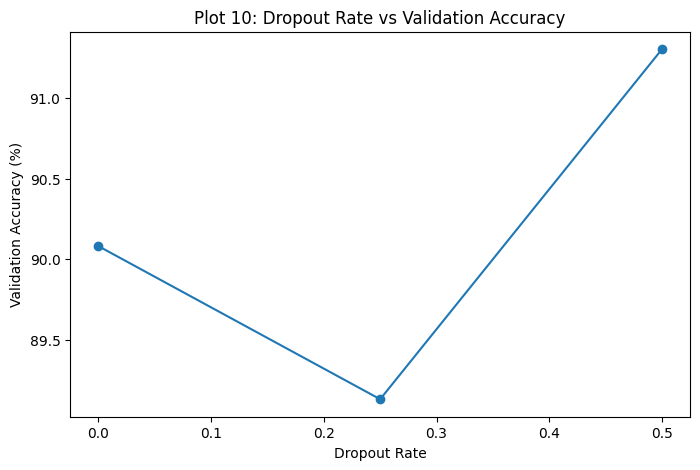

In [70]:
plt.figure(figsize=(8,5))
rates=list(dropout_results.keys())
accs=[dropout_results[r][0] for r in rates]
plt.plot(rates,accs,marker="o")
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.savefig("plot10_dropout_vs_acc.png",dpi=150,bbox_inches="tight")
plt.show()

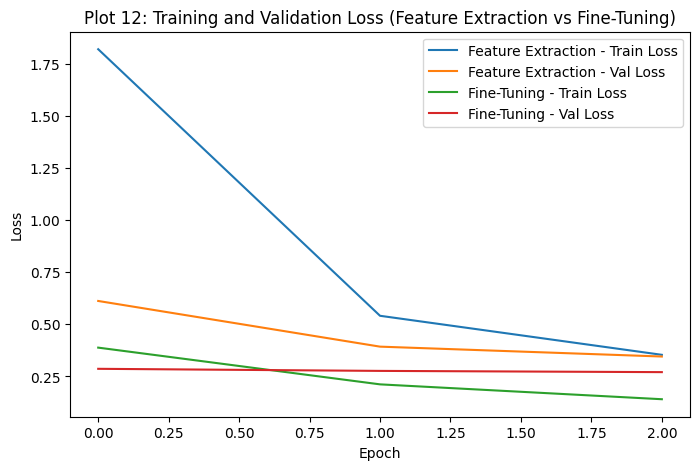

In [71]:
plt.figure(figsize=(8,5))
plt.plot(feature_history.history["loss"],label="Feature Extraction - Train Loss")
plt.plot(feature_history.history["val_loss"],label="Feature Extraction - Val Loss")
plt.plot(fine_history.history["loss"],label="Fine-Tuning - Train Loss")
plt.plot(fine_history.history["val_loss"],label="Fine-Tuning - Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training and Validation Loss (Feature Extraction vs Fine-Tuning)")
plt.legend()
plt.savefig("plot12_finetune_loss.png",dpi=150,bbox_inches="tight")
plt.show()